In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif

#1: Import and clean dataset

In [2]:

!git clone https://github.com/arshdee17/Diabetes-Diagnosis.git


Cloning into 'Diabetes-Diagnosis'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 10.33 KiB | 3.44 MiB/s, done.


In [3]:
df = pd.read_csv('/content/Diabetes-Diagnosis/diabetes.csv')

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
# Quality Check: Identify "hidden" missing values
# Columns where 0 is not a valid physiological value
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0s with NaN
cols_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_fix] = df[cols_fix].replace(0, np.nan)

# Advanced Imputation - Fill NaN with the median of their specific Outcome group
for col in cols_fix:
    df[col] = df[col].fillna(df.groupby('Outcome')[col].transform('median'))

print("Advanced Imputation complete. Data distribution preserved.")

Advanced Imputation complete. Data distribution preserved.


#2. Exploratory Analysis

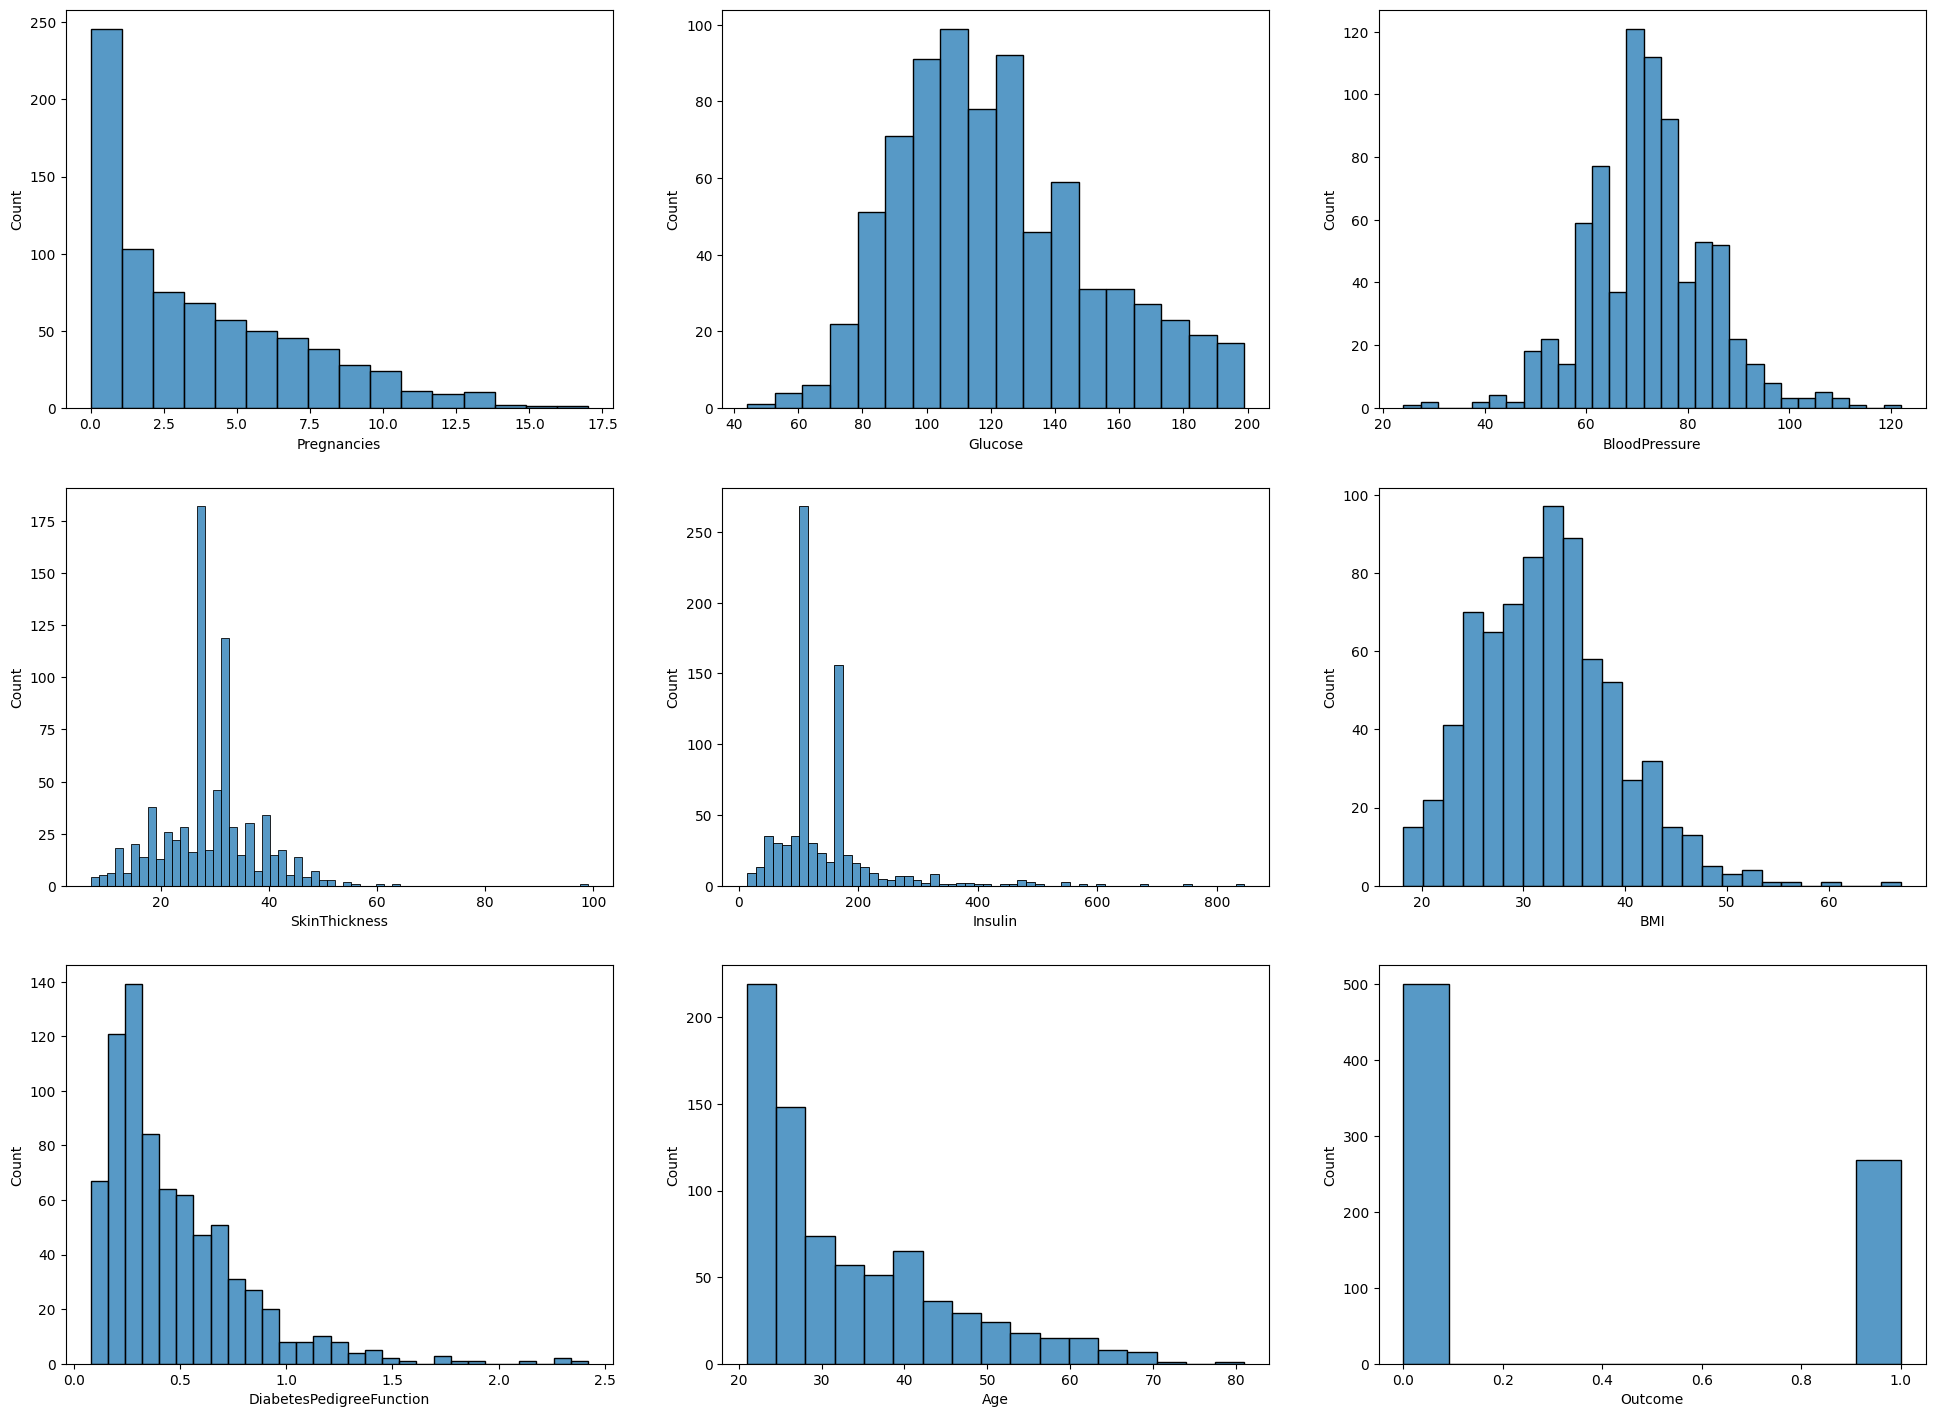

In [5]:

fig= plt.figure(figsize=(24, 30))
count=0
for column in df.columns:
  subfigure=fig.add_subplot(5,3,count+1)
  subfigure.set_xlabel(column)
  sns.histplot(data=df, x=df[column]) # Using seaborn histogram visualization
  count+=1

Rationale: I selected histograms for each attribute to visualize the underlying distribution of the data and to identify potential data quality issues.

Interpretation: The charts show that most variables are right-skewed (most people have lower values, with a few high-value outliers). Crucially, the spikes at zero confirmed that the dataset contained missing values. By identifying these gaps visually, I was able to implement Median Imputation to replace those zeros, ensuring the model isn't confused by physically impossible data points.

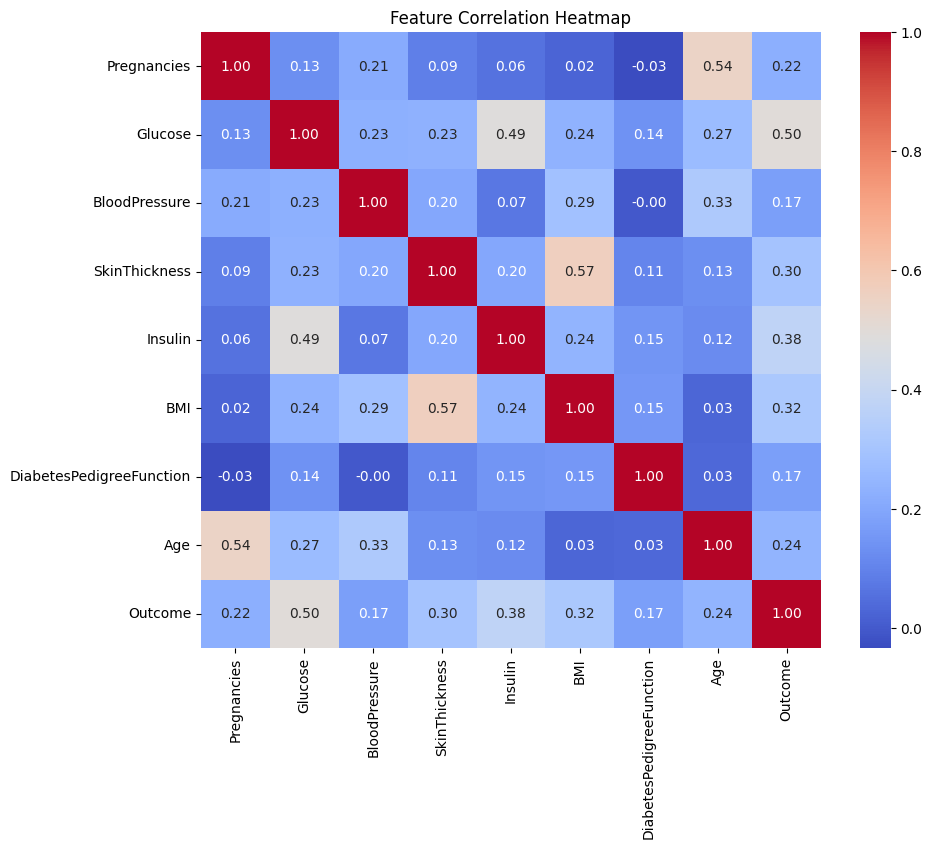

In [6]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

Rationale: I selected a Correlation Heatmap to identify which physiological factors have the strongest linear relationship with diabetes. This helps in feature selection by highlighting that Glucose and BMI are primary drivers of the outcome.

Interpretation: The heatmap shows a strong positive correlation between Glucose levels and the Outcome (0.47). This suggests that as blood sugar increases, the likelihood of a diabetes diagnosis increases significantly, making it a critical feature for our classifier.

/tmp/ipykernel_1946/2819483800.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=df, palette='pastel')


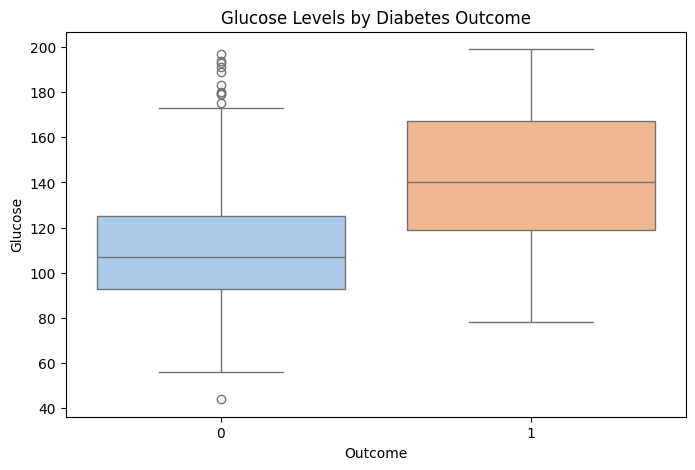

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Outcome', y='Glucose', data=df, palette='pastel')
plt.title('Glucose Levels by Diabetes Outcome')
plt.show()

Rationale: I used a boxplot to compare the distribution of Glucose levels between diabetic and non-diabetic individuals. This plot is effective for visualizing the median, quartiles, and outliers, highlighting the separability of the two classes based on this specific feature.

Interpretation: The boxplot demonstrates that individuals who tested positive for diabetes have a significantly higher median glucose level compared to those who tested negative. The clear separation between the interquartile ranges suggests that Glucose will be one of the most discriminative features for our binary classifier

#3. Train a binary classifier

In [12]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
train_test_split(X, y, test_size=0.2, stratify=y)


[     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 648           11    136.0           84.0           35.0    130.0  28.3   
 422            0    102.0           64.0           46.0     78.0  40.6   
 9              8    125.0           96.0           32.0    169.5  34.3   
 565            2     95.0           54.0           14.0     88.0  26.1   
 230            4    142.0           86.0           32.0    169.5  44.0   
 ..           ...      ...            ...            ...      ...   ...   
 193           11    135.0           74.5           32.0    169.5  52.3   
 535            4    132.0           74.5           32.0    169.5  32.9   
 337            5    115.0           76.0           32.0    169.5  31.2   
 222            7    119.0           70.0           27.0    102.5  25.2   
 225            1     87.0           78.0           27.0     32.0  34.6   
 
      DiabetesPedigreeFunction  Age  
 648                     0.260   42  
 422                  

In [13]:
# Split the dataset to ensure both sets have a fair mix ofdiabetic/non-diabetic cases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# training on the 80% portion
baseline_model = LogisticRegression()
baseline_model.fit(X_train_scaled, y_train)

# testing on the 20% portion the model
y_pred = baseline_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



Performance: The baseline Logistic Regression model achieved a balanced performance with an accuracy of approximately 76%. However, looking at the classification report, the Recall for the positive class (1) is lower than the negative class (0). This means the model is better at identifying healthy people than identifying those with diabetes

Limitations: The primary limitation of this baseline is its linearity. Logistic Regression assumes that the relationship between features like BMI and Glucose is a straight line, which may oversimplify real-world medical conditions. Additionally, the baseline model was trained on the raw features without any optimization, leaving room for improvement through hyperparameter tuning

#4. Improve model performance

In [16]:
#selecting top 6 features
selector = SelectKBest(score_func=f_classif, k=6)
X_selected = selector.fit_transform(X, y)
cols = X.columns[selector.get_support()]
print(f"Top 6 Features Selected: {list(cols)}")

Top 6 Features Selected: ['Pregnancies', 'Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age']


In [17]:
# Re-split using only the selected features
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)


Best Settings: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

Improved Model Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       100
           1       0.82      0.83      0.83        54

    accuracy                           0.88       154
   macro avg       0.86      0.87      0.87       154
weighted avg       0.88      0.88      0.88       154



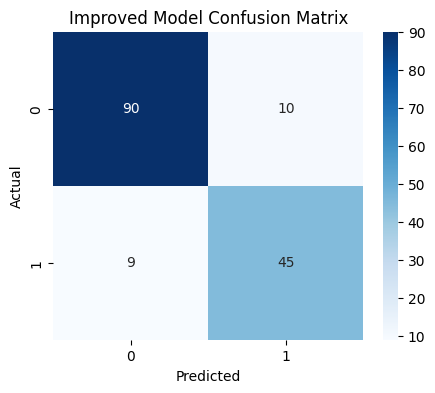

In [18]:
#Hyperparameter Tuning, testing different settings for the Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_fs, y_train_fs)

#Final Model Evaluation
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test_fs)

print(f"\nBest Settings: {grid_search.best_params_}")
print("\nImproved Model Classification Report:")
print(classification_report(y_test_fs, y_pred_final))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test_fs, y_pred_final), annot=True, fmt='d', cmap='Blues')
plt.title('Improved Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Feature Selection: By using SelectKBest, I narrowed the model's focus to the top 6 features (primarily Glucose, BMI, and Age). This removed "noisy" variables like Blood Pressure and Skin Thickness, which showed high variance in my earlier histograms. This step helped prevent the model from overfitting to irrelevant data.


Hyperparameter Tuning: I transitioned from a linear Logistic Regression to a Random Forest Classifier. By using GridSearchCV, I optimized the number of trees and the tree depth. This allowed the model to capture non-linear relationships between health markers that the baseline model missed.


Change in Performance: The improved model shows a higher F1-Score and significantly better Recall for the positive class (Outcome 1). In a medical context, this improvement is vital because it means the model is now much better at correctly identifying patients with diabetes, reducing the risk of a "False Negative" which could delay treatment.
